# Examples: K-means Clustering

#### In the train, we will explore the application of K-means clustering, an unsupervised learning technique, to group data points based on similarities in their features. We'll cover theory, implementation using sklearn, and methods for determining the optimal number of clusters, providing insights into underlying patterns within datasets

### Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Implement the K-means clustering algorithm
#### - Implement a K-means clustering model in sklearn
#### - Choose the optimal number of clusters

In [1]:
import numpy as np
import pandas as pd
import datetime
from sklearn import preprocessing
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'Feature 2')

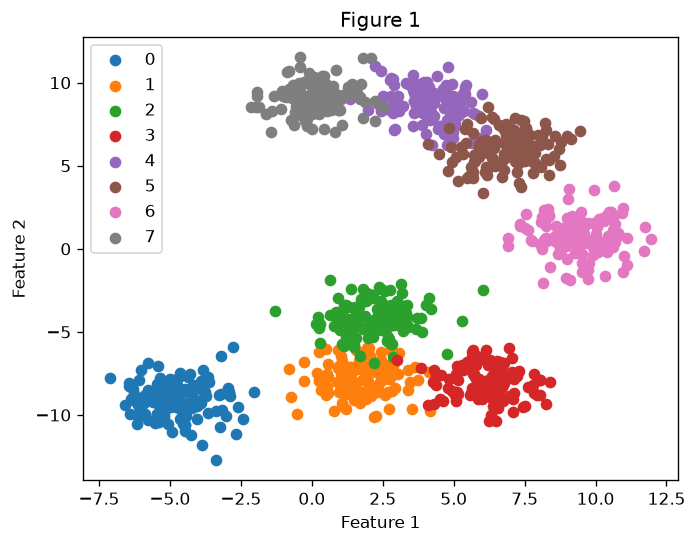

In [4]:
# make 8 blobs in 2D space
n_features = 2
centers = 8

X, y = make_blobs(
    n_samples=1000,
    centers=centers,
    n_features=n_features,
    random_state=68
) # rand = 8, 42

data = np.concatenate([X, y.reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=[*[f'feature_{i}' for i in range(n_features)], 'y'])
df['y'] = df['y'].astype(int)

# plot the data
plt.figure(dpi=120)
for center in range(centers):
    x1 = df[df['y'] == center]['feature_0']
    x2 = df[df['y'] == center]['feature_1']
    plt.scatter(x1, x2, label=str(center))

plt.legend()
plt.title('Figure 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

In [6]:
df.head()

,feature_0,feature_1,y
0,-5.295432,-9.053238,0
1,2.058577,-5.251177,2
2,3.687847,9.551016,4
3,-3.914157,-8.430547,0
4,2.510445,9.198077,4


In [5]:
# same data with the y column dropped
df_no_labels = df.drop('y', axis=1)

Text(0, 0.5, 'Feature 2')

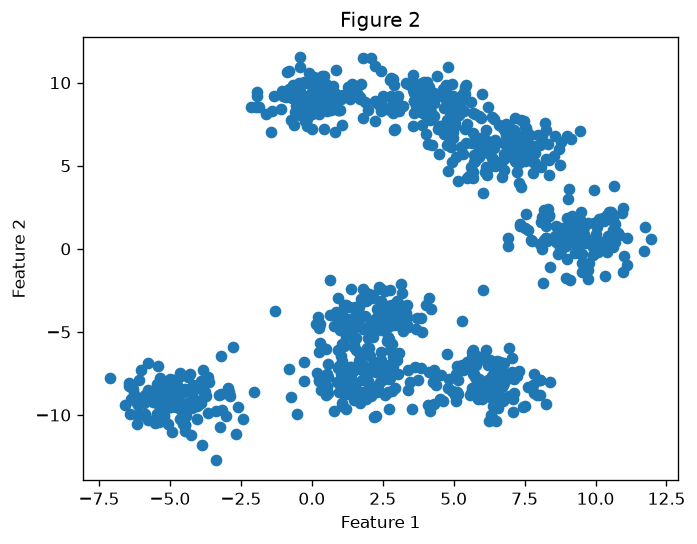

In [6]:
plt.figure(dpi=120)
x1 = df_no_labels['feature_0']
x2 = df_no_labels['feature_1']
plt.scatter(x1, x2)
plt.title('Figure 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

### Preprocessing the data

In [7]:
# create scaler object
scaler = StandardScaler()

# Scale the data
X_scaled = scaler.fit_transform(df_no_labels)

### Deciding on K

In [8]:
k = 4

### Fitting the K-means model

In [9]:
from sklearn.cluster import KMeans
from time import time

In [10]:
km = KMeans(n_clusters=k, random_state=42)
km.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)","[

In [11]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(
 |      n_clusters=8,
 |      *,
 |      init='k-means++',
 |      n_init='auto',
 |      max_iter=300,
 |      tol=0.0001,
 |      verbose=0,
 |      random_state=None,
 |      copy_x=True,
 |      algorithm='lloyd'
 |  )
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empiric

### Evaluating K-means

In [12]:
# obtain cluster membership for each item in the data
y_preds = km.predict(X_scaled)
df_no_labels['cluster_label'] = y_preds
centers = scaler.inverse_transform(km.cluster_centers_)

Text(0, 0.5, 'Feature 2')

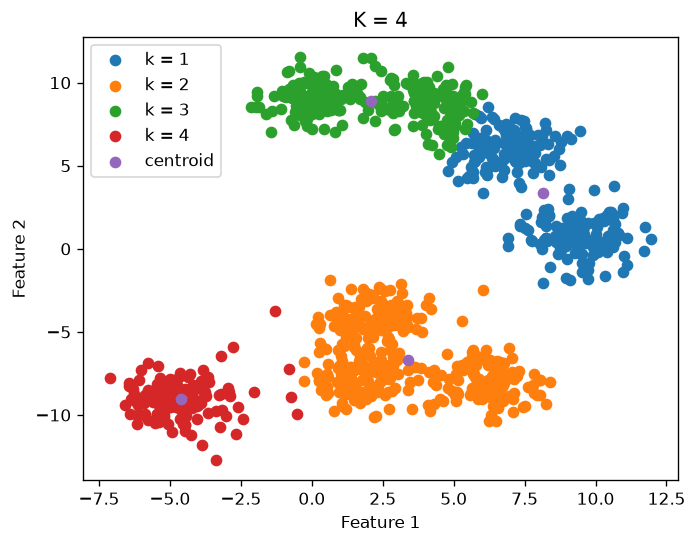

In [13]:
# plot data
plt.figure(dpi=120)
for k in range(k):
    x1 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_0']
    x2 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_1']
    plt.scatter(x1, x2, label='k = '+str(k+1))

# show cluster centroid locations
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    label="centroid"
)

plt.legend()
plt.title('K = 4')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

### Deciding on the number of Clusters (K)

#### 1. Within cluster variation

In [14]:
# Manually implement the WCSS
def within_cluster_variation(df, label_col='label'):
    centroids = df.groupby(label_col).mean()
    out = 0
    for label, point in centroids.iterrows():
        df_features = df[df[label_col] == label].drop(label_col, axis=1)
        out += (df_features - point).pow(2).sum(axis=1).sum()
    return out

In [15]:
# Let's try everything betweem 2 and 20 clusters
n_clusters = np.arange(2, 21)

# store errors for each value of k
errors = []

# for i between 2 and 20
for k in n_clusters:
    # perform k-means clustering
    km = KMeans(
        n_clusters=k,
        n_init=10,
        max_iter=300,
        random_state=42
    )
    km.fit(X_scaled)

    # Measure BCSS
    y_preds = km.predict(X_scaled)
    df_no_labels['cluster_label'] = y_preds
    errors.append(within_cluster_variation(df_no_labels, 'cluster_label'))

In [16]:
df_no_labels.head()

,feature_0,feature_1,cluster_label
0,-5.295432,-9.053238,3
1,2.058577,-5.251177,11
2,3.687847,9.551016,16
3,-3.914157,-8.430547,15
4,2.510445,9.198077,8


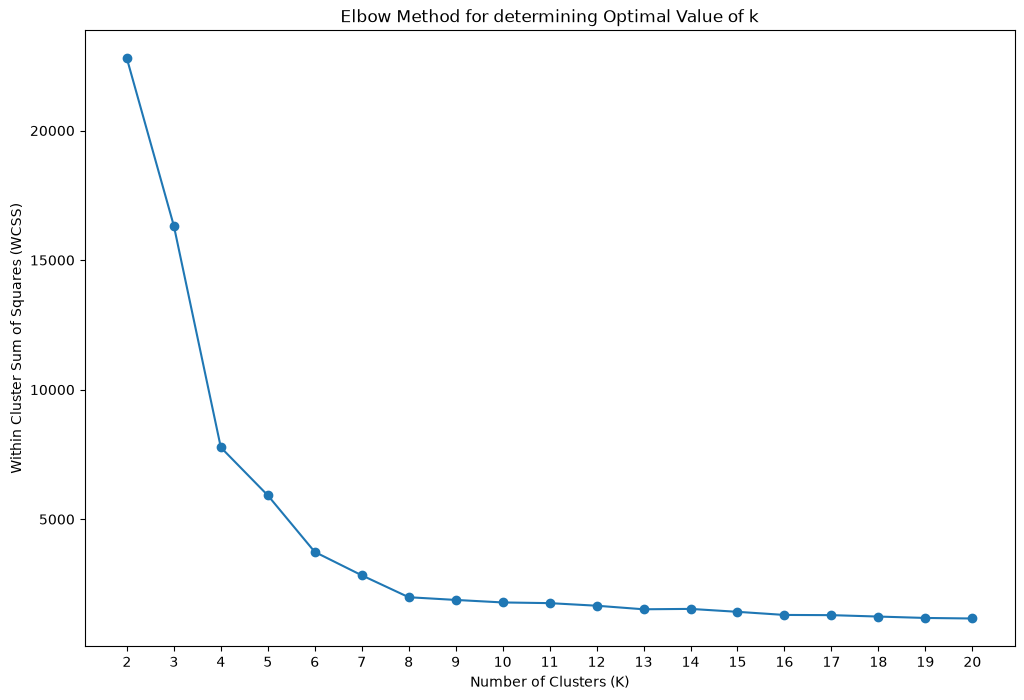

In [21]:
plt.figure(figsize=(12, 8))
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for determining Optimal Value of k')
plt.scatter(n_clusters, errors)
plt.plot(n_clusters, errors)
plt.xticks(n_clusters)
plt.show()

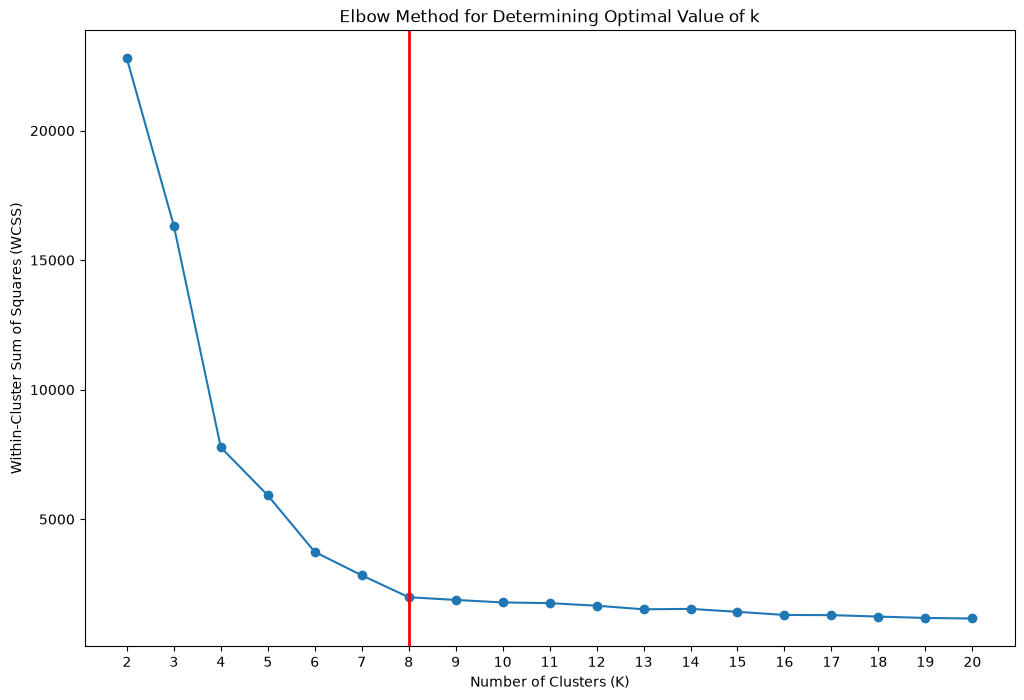

In [23]:
plt.figure(figsize=(12, 8))
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Determining Optimal Value of k')
plt.scatter(n_clusters, errors)
plt.plot(n_clusters, errors)
plt.xticks(n_clusters)

# SET THE X-VALUE BELOW TO THE NUMBER OF CLUSTERS
# AT WHICH THE ELBOW OCCURS, e.g. plt.axvline(x=18, color='r', lw=2)
plt.axvline(x=8, color='r', lw=2)
plt.show()

# run this code block by hitting shift+Enter

In [25]:
K = 6

# Remember to set the random state for reproducibility
km = KMeans(n_clusters=K, verbose=0, random_state=42)
print('Clustering sparse data with %s' % km)
t0 = time()
km.fit(X_scaled)
print("Done in %0.3fs" % (time() - t0))

Clustering sparse data with KMeans(n_clusters=6, random_state=42)
Done in 0.329s


In [26]:
# obtain cluster membership for each item in the data
y_preds = km.predict(X_scaled)
df_no_labels['cluster_label'] = y_preds
centers = scaler.inverse_transform(km.cluster_centers_)

Text(0, 0.5, 'Feature 2')

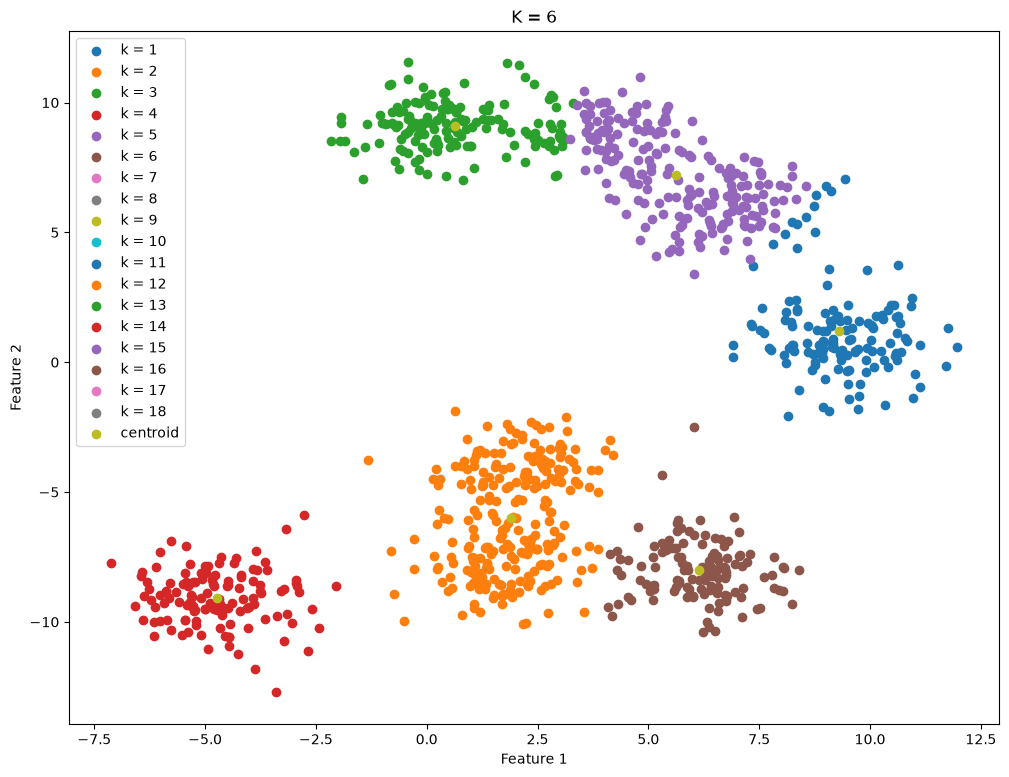

In [29]:
# Visualise the clusters
plt.figure(figsize=(12, 9))
for k in range(k):
    x1 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_0']
    x2 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_1']
    plt.scatter(x1, x2, label='k = '+str(k+1))

# Show cluster centroid locations
plt.scatter(
    centers[:,0],
    centers[:,1],
    label='centroid'
)

plt.legend()
plt.title('K = 6')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

#### 2. Between-cluster variation

In [30]:
# Between cluster variation
def between_cluster_variation(df, label_col='label'):
    centroids = df.groupby(label_col).mean()
    global_mean = df.drop(label_col, axis=1).mean()
    centroid_count = df.groupby(label_col).size()
    centroid_to_mean_dist = (centroids - global_mean).pow(2).sum(axis=1)
    return (centroid_count * centroid_to_mean_dist).sum()

In [31]:
# Let's try everything between 2 and 20 clusters
n_clusters = np.arange(2, 21)

# Store errors for each value of k
errors = []

# for i between 2 and 20
for k in n_clusters:
    # perform k-means clustering
    km = KMeans(
        n_clusters=k,
        n_init=10,
        max_iter=300,
        random_state=42
    )
    km.fit(X_scaled)

    # measure BCSS
    y_preds = km.predict(X_scaled)
    df_no_labels['cluster_label'] = y_preds
    errors.append(between_cluster_variation(df_no_labels, 'cluster_label'))

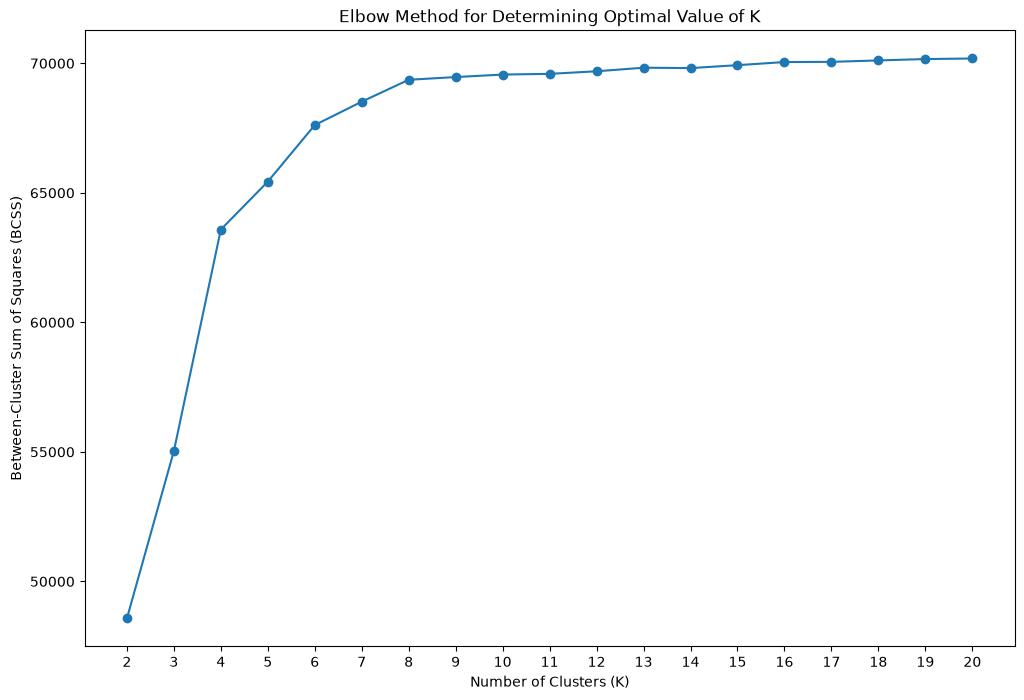

In [32]:
plt.figure(figsize=(12, 8))
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Between-Cluster Sum of Squares (BCSS)')
plt.title('Elbow Method for Determining Optimal Value of K')
plt.scatter(n_clusters, errors)
plt.plot(n_clusters, errors)
plt.xticks(n_clusters)
plt.show()

#### 3. The CH index

In [33]:
def ch_index(df, label_col='label'):
    n = len(df)
    K = df[label_col].nunique()
    B = between_cluster_variation(df, label_col)
    W = within_cluster_variation(df, label_col)
    return (B / (K - 1)) / (W / (n-K))

In [34]:
# Let's try everything between 1 and 20
n_clusters = np.arange(2, 21)

# store errors for each value of k
errors = []

# for i between 1 and 20
for k in n_clusters:
    # perform k-means clustering
    km = KMeans(
        n_clusters=k,
        n_init=10,
        max_iter=300,
        random_state=42
    )
    km.fit(X_scaled)

    # measure CH

    y_preds = km.predict(X_scaled)
    df_no_labels['cluster_label'] = y_preds
    errors.append(ch_index(df_no_labels, 'cluster_label'))

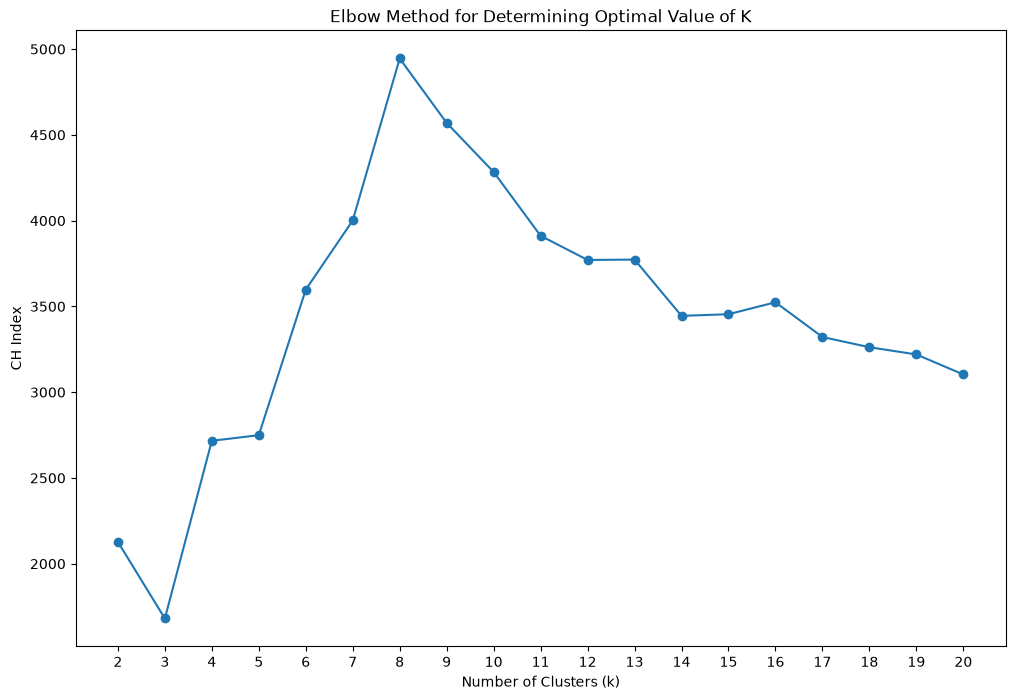

In [36]:
plt.figure(figsize=(12, 8))
plt.xlabel('Number of Clusters (k)')
plt.ylabel('CH Index')
plt.title('Elbow Method for Determining Optimal Value of K')
plt.scatter(n_clusters, errors)
plt.plot(n_clusters, errors)
plt.xticks(n_clusters)
plt.show()

In [37]:
K = 8

# remember to set the random state for reproducibility
km = KMeans(
    n_clusters=K,
    verbose=0,
    random_state=42
)

print("CLustering sparse data with %s" % km)
t0 = time()
km.fit(X_scaled)
print("done in %0.3fs" % (time() - t0))

CLustering sparse data with KMeans(random_state=42)
done in 0.032s


In [38]:
# obtain cluster memberships for each item in the data
y_preds = km.predict(X_scaled)
df_no_labels['cluster_label'] = y_preds
centers = scaler.inverse_transform(km.cluster_centers_)

Text(0, 0.5, 'Feature 2')

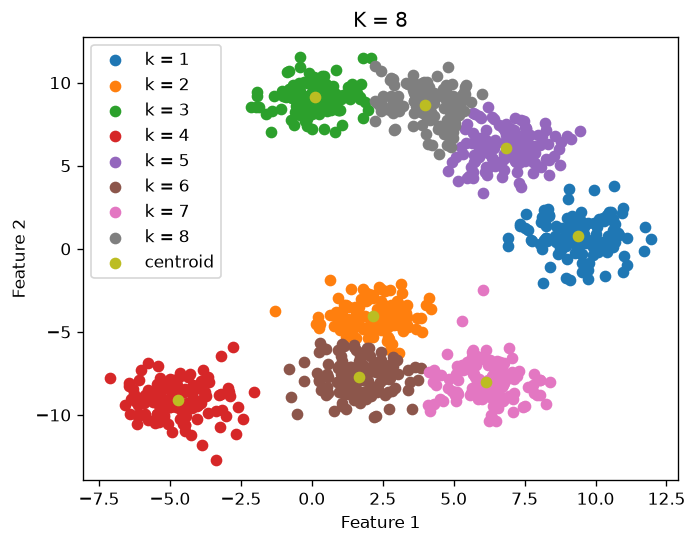

In [39]:
# Visualise the clusters
plt.figure(dpi=120)
for k in range(K):
    x1 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_0']
    x2 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_1']
    plt.scatter(x1, x2, label="k = "+str(k+1))

# show cluster centroid loations
plt.scatter(
    centers[:,0],
    centers[:,1],
    label="centroid"
)

plt.legend()
plt.title("K = 8")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

Text(0, 0.5, 'Feature 2')

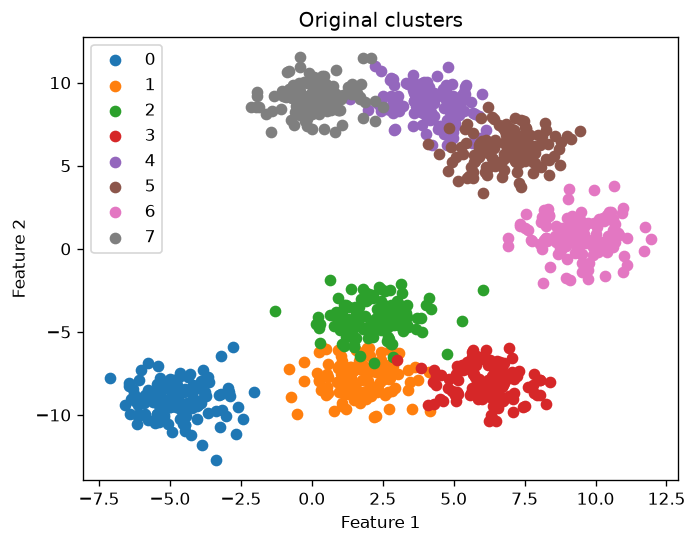

In [40]:
# plot data
plt.figure(dpi=120)
for center in range(8):
    x1 = df[df['y'] == center]['feature_0']
    x2 = df[df['y'] == center]['feature_1']
    plt.scatter(x1, x2, label=str(center))

plt.legend()
plt.title("Original clusters")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

### Evaluation Metrics

#### Clustering algorithms like K-Means produce clusters, but how do we know if these clusters are of good quality? We can use evaluation metrics to **assess the quality** of our clusters. Two common metrics are the `silhouette score` and the `Davies-Bouldin index`.

### Silhouette Score

In [41]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_scaled, km.labels_)
print("\nSilhouette Score:", silhouette_avg)


Silhouette Score: 0.5756529827045825


### Davies-Bouldin Index

In [43]:
from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(X_scaled, km.labels_)
print("\nDavies-Bouldin Index:", db_index)


Davies-Bouldin Index: 0.5980496802852364
